<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Duplicates Lab**


Estimated time needed: **30** minutes


## Introduction


Data wrangling is a critical step in preparing datasets for analysis, and handling duplicates plays a key role in ensuring data accuracy. In this lab, you will focus on identifying and removing duplicate entries from your dataset. 


## Objectives


In this lab, you will perform the following:


1. Identify duplicate rows in the dataset and analyze their characteristics.
2. Visualize the distribution of duplicates based on key attributes.
3. Remove duplicate values strategically based on specific criteria.
4. Outline the process of verifying and documenting duplicate removal.


## Hands on Lab


Install the needed library


In [1]:
!pip install pandas
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 123.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 79.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 144.4 MB/s eta 0:00:00


Import pandas module


In [2]:
import pandas as pd


Import matplotlib


In [3]:
import matplotlib.pyplot as plt


## **Load the dataset into a dataframe**


<h2>Read Data</h2>
<p>
We utilize the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


In [58]:
# Load the dataset directly from the URL
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv"
df = pd.read_csv(file_path)

# Display the first few rows
print(df.head())

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

Load the data into a pandas dataframe:



Note: If you are working on a local Jupyter environment, you can use the URL directly in the pandas.read_csv() function as shown below:



In [59]:
# df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


## Identify and Analyze Duplicates


### Task 1: Identify Duplicate Rows
1. Count the number of duplicate rows in the dataset.
3. Display the first few duplicate rows to understand their structure.


In [60]:
## Write your code here

# count number of duplicate rows in dataframe
duplicate_count = df.duplicated().sum()
print(f'The number of duplicate rows in the dataset is {duplicate_count}')

(df[df.duplicated()].head())

The number of duplicate rows in the dataset is 20


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
65437,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65438,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
65439,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
65440,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
65441,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 2: Analysis of Duplicate Response Patterns
1. Identify duplicate response patterns based on selected columns such as MainBranch, Employment, and RemoteWork.
2. Clarify that these represent multiple respondents with identical answers rather than duplicate records. Analyse which other columns frequently share identical values within these response-pattern groups.
   


In [64]:
## Write your code here

#identify duplicate response patterns based on selected columns such as MainBranch, Employment, and RemoteWork
select_columns = ['MainBranch', 'Employment', 'RemoteWork']

# Using a for loop to get the number of unique inputs for each selected column
for col in select_columns:
    if col in df.columns:
        unique_count = df[col].nunique()
        print(f'Column: {col} has {unique_count} unique inputs, and likely represent multiple responders with identical answers rather than duplicate records')
        
#Analyze other columns frequently sharing identical values within these response-pattern groups
other_columns = [col for col in df.columns if col not in select_columns]

#created a for loop that counts the number of unique values, but the output was long, tried a different approach by groupby below
#for col in other_columns:
    #if col in df.columns:
       # unique_count = df[col].nunique()
       # print(f'Column: {col} has {unique_count} unique inputs')

# filter responders who share identical profile pattern
ident_profile = df[df.duplicated(subset=select_columns, keep =False)]

# group by pattern and calculate nunique for other columns
ident_data = ident_profile.groupby(select_columns)[other_columns].nunique()

ident_freq = (ident_data == 1).mean() * 100

print(f'The columns with most frequent identical values within MainBranch, Employment, and RemoteWork are: {ident_freq.sort_values(ascending=False).head(10)}')

print(f'The columns with least frequent identical values within MainBranch, Employment, and RemoteWork are: {ident_freq.sort_values(ascending=True).head(10)}')


Column: MainBranch has 5 unique inputs, and likely represent multiple responders with identical answers rather than duplicate records
Column: Employment has 110 unique inputs, and likely represent multiple responders with identical answers rather than duplicate records
Column: RemoteWork has 3 unique inputs, and likely represent multiple responders with identical answers rather than duplicate records
The columns with most frequent identical values within MainBranch, Employment, and RemoteWork are: Check                         100.000000
shared                        100.000000
ICorPM                         30.407524
AIThreat                       27.586207
SOAccount                      26.645768
AINextLess integrated          23.824451
AISelect                       23.510972
SurveyLength                   23.510972
AINextMuch more integrated     23.197492
SOPartFreq                     21.003135
dtype: float64
The columns with least frequent identical values within MainBranch, Empl

### Task 3: Visualize Shared Response Patterns
1. Create visualizations to show the distribution of shared response patterns across different categories.
2. Use bar charts or pie charts to represent the distribution of respondents who share identical values for MainBranch, Employment, and RemoteWork, grouped by Country and Employment.


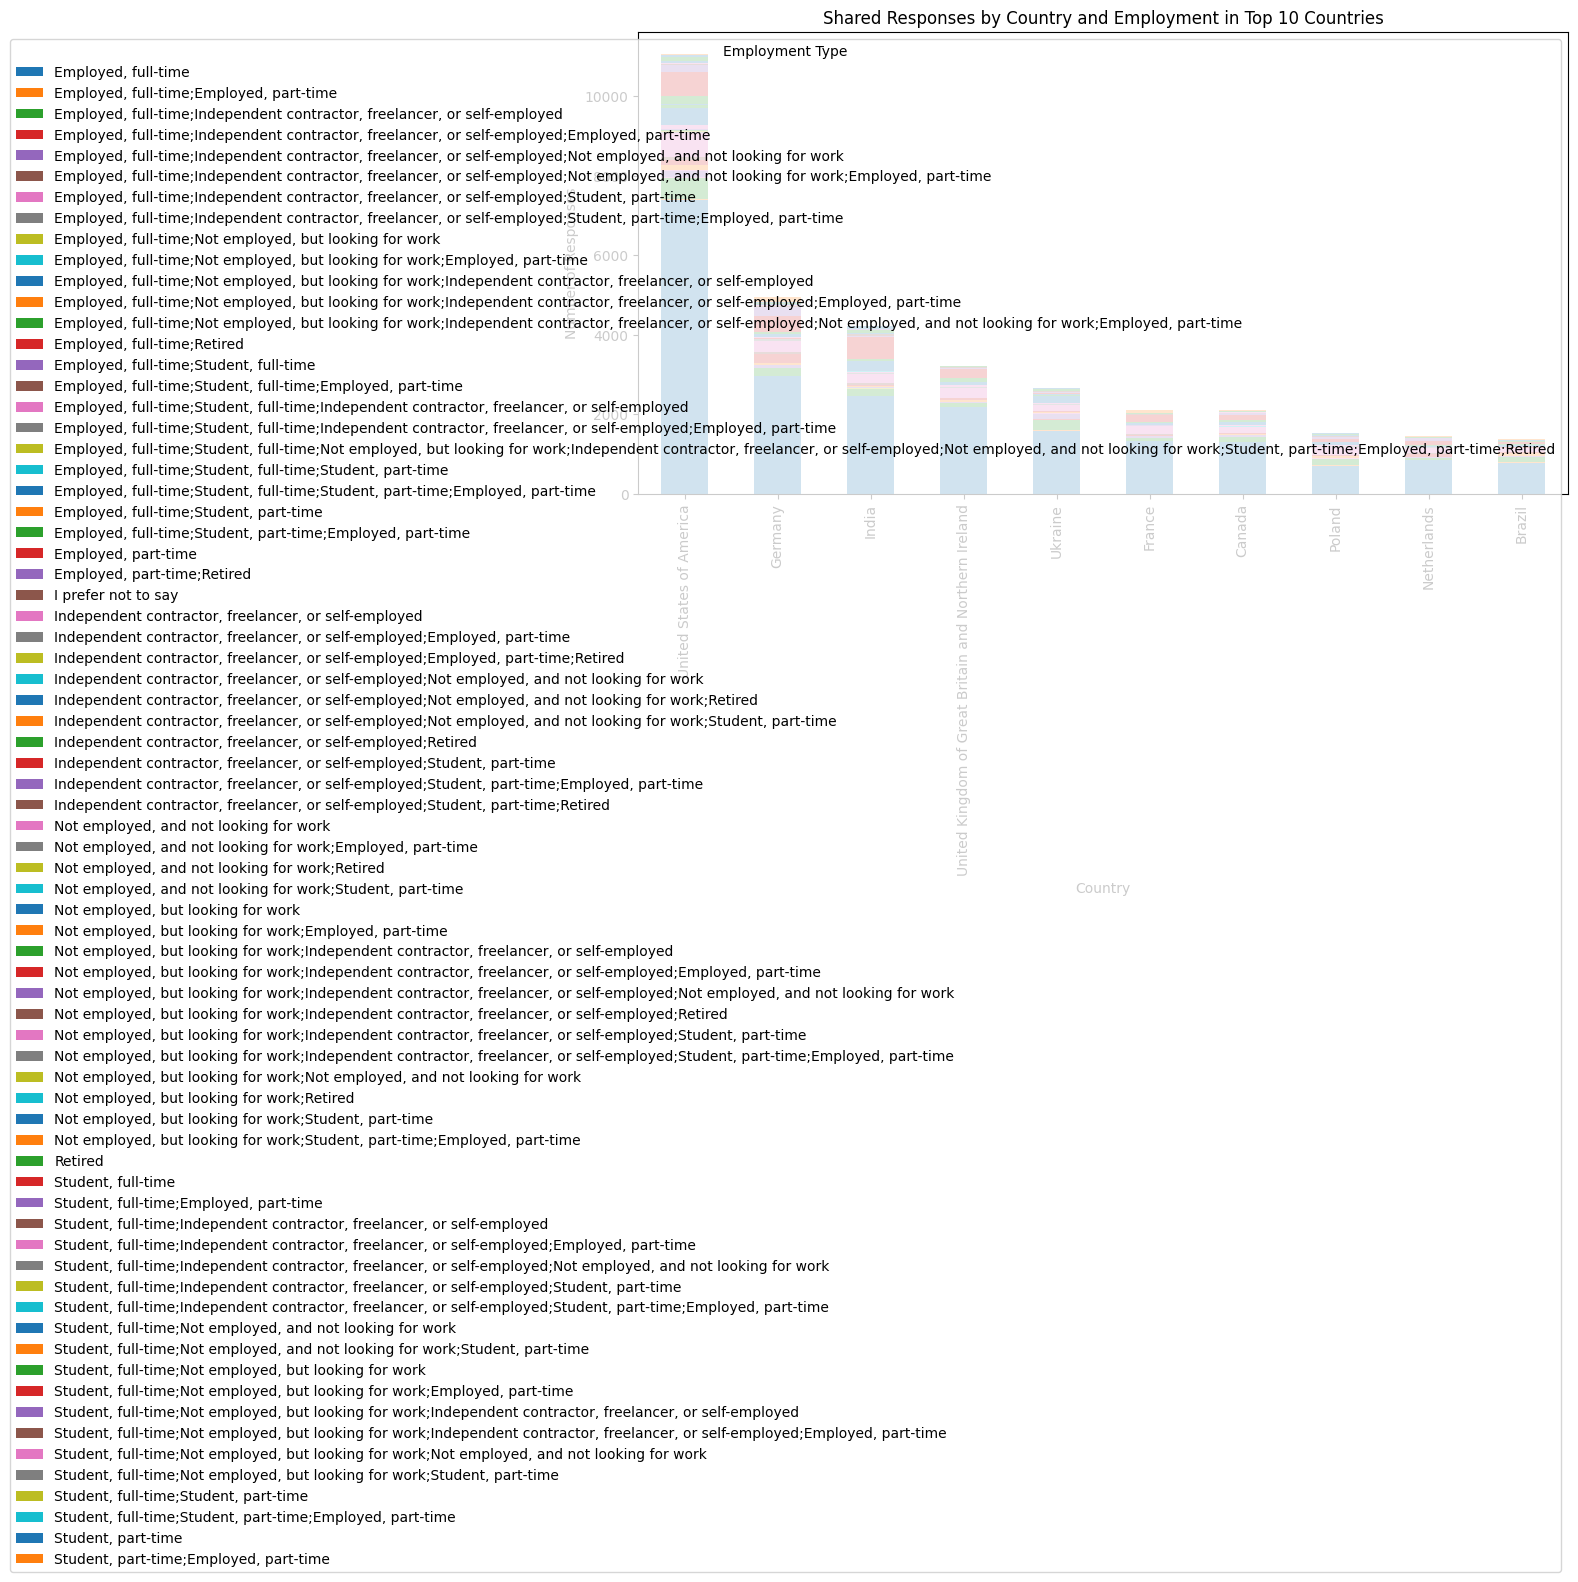

In [62]:
## Write your code here

#Create pie charts to represent distribution of respondents who share identical values for Mainbranch, Employment, and RemoteWork grouped by Country and Employment
#Start by identifying rows that are a similar shared response
df['shared'] = df.duplicated(subset = select_columns, keep=False)
shared_df = df[df['shared'] ==True]

#Group by country and employment
#df_group = shared_df.groupby(['Country', 'Employment']).size().unstack(fill_value=0)

# look at top 10 countries 
top_10_countries = shared_df['Country'].value_counts().nlargest(10).index

# create table and filter it using .loc to limit datagrame to 10 top countries
plot_data=(shared_df.groupby(['Country', 'Employment']).size().unstack(fill_value=0).loc[top_10_countries])

# Generate bar charts
plot_data.plot(kind='bar', stacked=True, figsize = (12, 6))
plt.title('Shared Responses by Country and Employment in Top 10 Countries')
plt.ylabel('Number of Responses')
plt.legend(title='Employment Type')
plt.show()

#Pie charts
#employment_df = df_group['Employment'].value_counts(sort=True, ascending = False).head(10)
#employment_df.plot(kind = 'pie', autopct = '%1.1f%%', startangle = 90, figsize = (10, 10))
#plt.title('Employment with shared responses')
#plt.ylabel('')
#plt.show()

#df_group.head()

### Task 4: Evaluate Duplicate Handling Strategy
1. Analyse the dataset to determine which column(s) define record uniqueness.
2. Assess whether removing rows based on a subset of columns (rather than complete row duplication) is appropriate.
Justify your decision with reference to the structure and purpose of the dataset.


In [57]:
# count number of rows
total_rows = len(df)

#check number of unique values in ResponseId column
unique_resonseid = df['ResponseId'].nunique()

print(f'Total Rows: {total_rows}')
print(f'Unique responders: {unique_resonseid}')


Total Rows: 65457
Unique responders: 65437


## Verify and Document Duplicate Removal Process


### Task 5: Documentation
1. Document the process of identifying and removing duplicates.


In [63]:
# 1. Get the total number of rows
total_rows = len(df)
print(f"Total Rows in Dataset: {total_rows}\n")

# 2. Loop through every column to check for uniqueness
for col in df.columns:
    unique_count = df[col].nunique()
    
    if unique_count == total_rows:
        print(f"✅ {col}: UNIQUE (matches all {total_rows} rows)")
    else:
        duplicates = total_rows - unique_count
        print(f"❌ {col}: NOT UNIQUE ({duplicates} duplicate values found)")

Total Rows in Dataset: 65457

❌ ResponseId: NOT UNIQUE (20 duplicate values found)
❌ MainBranch: NOT UNIQUE (65452 duplicate values found)
❌ Age: NOT UNIQUE (65449 duplicate values found)
❌ Employment: NOT UNIQUE (65347 duplicate values found)
❌ RemoteWork: NOT UNIQUE (65454 duplicate values found)
❌ Check: NOT UNIQUE (65456 duplicate values found)
❌ CodingActivities: NOT UNIQUE (65339 duplicate values found)
❌ EdLevel: NOT UNIQUE (65449 duplicate values found)
❌ LearnCode: NOT UNIQUE (65039 duplicate values found)
❌ LearnCodeOnline: NOT UNIQUE (54604 duplicate values found)
❌ TechDoc: NOT UNIQUE (65344 duplicate values found)
❌ YearsCode: NOT UNIQUE (65405 duplicate values found)
❌ YearsCodePro: NOT UNIQUE (65405 duplicate values found)
❌ DevType: NOT UNIQUE (65423 duplicate values found)
❌ OrgSize: NOT UNIQUE (65447 duplicate values found)
❌ PurchaseInfluence: NOT UNIQUE (65454 duplicate values found)
❌ BuyNewTool: NOT UNIQUE (65242 duplicate values found)
❌ BuildvsBuy: NOT UNIQUE (6

2. Explain the reasoning behind selecting specific columns for identifying and removing duplicates.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-11- 05|1.3|Madhusudhan Moole|Updated lab|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-09-24|1.1|Madhusudhan Moole|Updated lab|
|2024-09-23|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
